# Lilium Tower Optimization

In [1]:
import parametrization, sparse_matrices, mesh, numpy as np, importlib, pickle, wall_generation
from tri_mesh_viewer import TriMeshViewer
import vis, matplotlib
from py_newton_optimizer import NewtonOptimizerOptions
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization, wall_width_formulas as wwf

In [2]:
lilium = mesh.Mesh("../examples/lilium.msh")
lilium = lilium.subdivide_loop(1)

In [3]:
# Choose reasonable stretching bounds
alphaMin = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(2, 10))
alphaMax = wwf.stretchFactorForCanonicalWallWidth(wwf.canonicalWallWidthForGeometry(1, 10))
print(alphaMin, alphaMax)

1.4098490006173308 1.4859772889704024


In [4]:
lg = parametrization.LocalGlobalParametrizer(lilium, parametrization.lscm(lilium))

for i in range(1000): lg.runIteration()
print(lg.energy())
lg.alphaMin = 1.4
lg.alphaMax = np.pi / 2

print(lg.energy())
lg.runIteration()
print(lg.energy())

rparam = parametrization.RegularizedParametrizerSVD(lg)
for i in range(50): lg.runIteration()
print(lg.energy())

0.01387869112344026
0.3351331003568487
0.034739560879584366
0.0007008183916330019


In [5]:
rparam = parametrization.RegularizedParametrizerSVD(lilium, lg.uv())
rparam.alphaMin = alphaMin
rparam.alphaMax = alphaMax

In [6]:
def optimize_rparam(param, alphaRegW, phiRegW, bendRegWeight):
    param.alphaRegW = alphaRegW
    param.phiRegW = phiRegW
    param.bendRegW = bendRegWeight
    opts = NewtonOptimizerOptions()
    opts.useIdentityMetric = True
    opts.beta = 1e-4
    opts.niter = 2000
    opts.gradTol = 1e-10
    parametrization.benchmark_reset()
    cr = parametrization.regularized_parametrization_newton(param, param.rigidMotionPinVars, opts)
    parametrization.benchmark_report()

In [7]:
parametrization.benchmark_reset()
with suppress_stdout(): optimize_rparam(rparam, 1e-4, 1e-4, 1e-2)
with suppress_stdout(): optimize_rparam(rparam, 1e-5, 1e-5, 1e-3)
with suppress_stdout(): optimize_rparam(rparam, 1e-6, 1e-6, 1e-3)
with suppress_stdout(): optimize_rparam(rparam, 1e-7, 1e-7, 1e-4)
with suppress_stdout(): optimize_rparam(rparam, 0.5e-7, 0.5e-7, 1e-4)
with suppress_stdout(): optimize_rparam(rparam, 0.2e-7, 0.2e-7, 1e-4)
with suppress_stdout(): optimize_rparam(rparam, 1e-7, 1e-7, 1e-4)
parametrization.benchmark_report()

Newton iterations	374.756	1
    Newton iterate	374.748	898
        Backtracking	6.84176	897
            Update SVD Sensitivities	1.22705	1029
        Compute descent direction	355.7	897
            newton_step	355.655	897
                Newton solve	180.985	2231
                    CHOLMOD Numeric Factorize	168.306	2231
                    Solve	8.22191	897
                        CHOLMOD Backsub	8.17192	897
                hessEval	174.568	897
        RegularizedParametrizerSVD gradient	8.23774	898
Update SVD Sensitivities	0.00124002	1
CHOLMOD Symbolic Factorize	0.0359578	1
Full time	374.823


In [37]:
PET = parametrization.RegularizedParametrizerSVD.EnergyType
[rparam.energy(et) / reg for (et, reg) in [(PET.Fitting, 1.0), (PET.AlphaRegularization, rparam.alphaRegW), (PET.PhiRegularization, rparam.phiRegW), (PET.BendingRegularization, rparam.bendRegW)]]

[3.190041407739422e-05,
 7.93460116527748,
 88.37406334361312,
 1.0926898134821446]

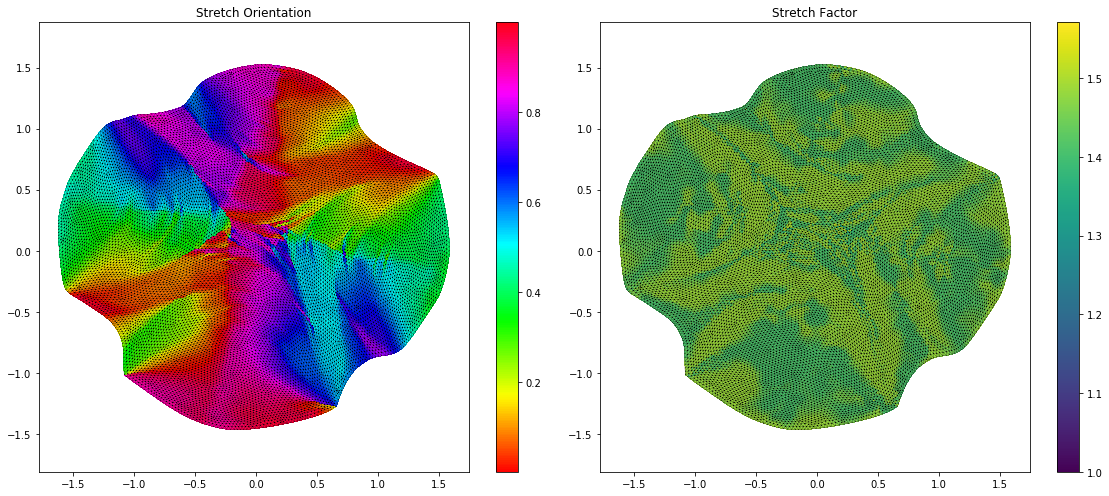

In [38]:
visualization.visualize(rparam)

In [39]:
kappa_idx = 0
tri_kappa = np.array([rparam.curvature3d(i, kappa_idx)[0] for i in range(lilium.numTris())])
tri_d = np.array([rparam.curvature3d(i, kappa_idx)[1] for i in range(lilium.numTris())])

In [42]:
vectors = rparam.tubeDirections()
#vectors = ci.d_1
#vectors = tri_d
vf = vis.fields.VectorField(vectors, glyph=vis.fields.VectorGlyph.CYLINDER, colormap=matplotlib.cm.viridis, align=vis.fields.VectorAlignment.CENTER)
sf = vis.fields.ScalarField(tri_kappa, colormap=matplotlib.cm.viridis, domainType=vis.fields.DomainType.PER_TRI)
#vf = None
viewer = TriMeshViewer(lilium, width=1400, height=640, vectorField=vf, scalarField=sf)
viewer.arrowSize = 40
#viewer.showWireframe()
viewer.setCameraParams(((0.5860034920267359, -3.035291050193042, 0.6228616949298365),
 (-0.0173304352854086, 0.39865202259301563, 0.9169385044239974),
 (-0.07872449082034016, -0.22380850423877954, -0.6120338005211532)))
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=2.1875, children=(DirectionalLight(color='white', intensity=0.6, posi…

In [44]:
np.savetxt('results/lilium_subdiv/param_5.txt', rparam.uv())

In [46]:
widths = wwf.wallWidthForCanonicalWidth(wwf.canonicalWallWidthForStretchFactor(rparam.getAlphas()), 10)
(np.min(widths), np.max(widths))

(0.653843487506053, 2.9375010396844905)

## Upsampling and channel generation

In [117]:
# upsampledMesh.save('results/lilium_subdiv/param_5_upsampledMesh.msh')
# np.savetxt('results/lilium_subdiv/param_5_upsampledAngles.txt', upsampledAngles)
# np.savetxt('results/lilium_subdiv/param_5_upsampledStretches.txt', upsampledStretches)
upsampledMesh = mesh.Mesh('results/lilium_subdiv/param_5_upsampledMesh.msh')
upsampledAngles = np.loadtxt('results/lilium_subdiv/param_5_upsampledAngles.txt')
upsampledStretches = np.loadtxt('results/lilium_subdiv/param_5_upsampledStretches.txt')

In [89]:
nsubdiv=4
upsampledMesh, upsampledAngles, upsampledStretches = rparam.upsampledVertexLeftStretchAnglesAndMagnitudes(nsubdiv)
(sdfVertices, sdfTris, sdf) = wall_generation.evaluate_stripe_field(upsampledMesh.vertices(), upsampledMesh.triangles(), upsampledAngles,
                                                                    wwf.canonicalWallWidthForStretchFactor(upsampledStretches), frequency=125)

In [ ]:
import pickle, mesh, wall_generation, visualization, numpy as np

In [90]:
pickle.dump((sdfVertices, sdfTris, sdf), open('results/lilium_subdiv/param_5_sdf_ns4_f100.pkl', 'wb'))

In [95]:
(sdfVertices, sdfTris, sdf) = pickle.load(open('results/lilium_subdiv/param_5_sdf_ns4_f125.pkl', 'rb'))

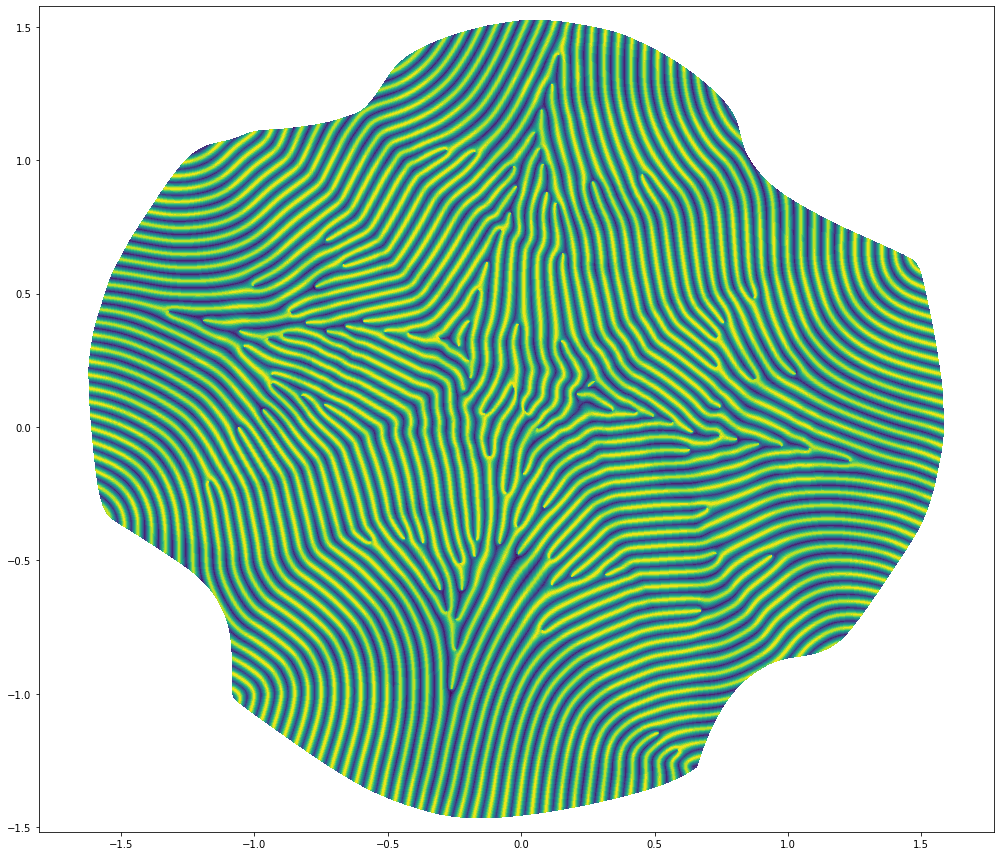

In [96]:
visualization.scalarFieldPlotFast(sdfVertices, sdfTris, sdf, height=12)

In [97]:
pts, edges = wall_generation.extract_contours(sdfVertices, sdfTris, sdf,
                                              targetEdgeSpacing=0.01,
                                              minContourLen=0.075)

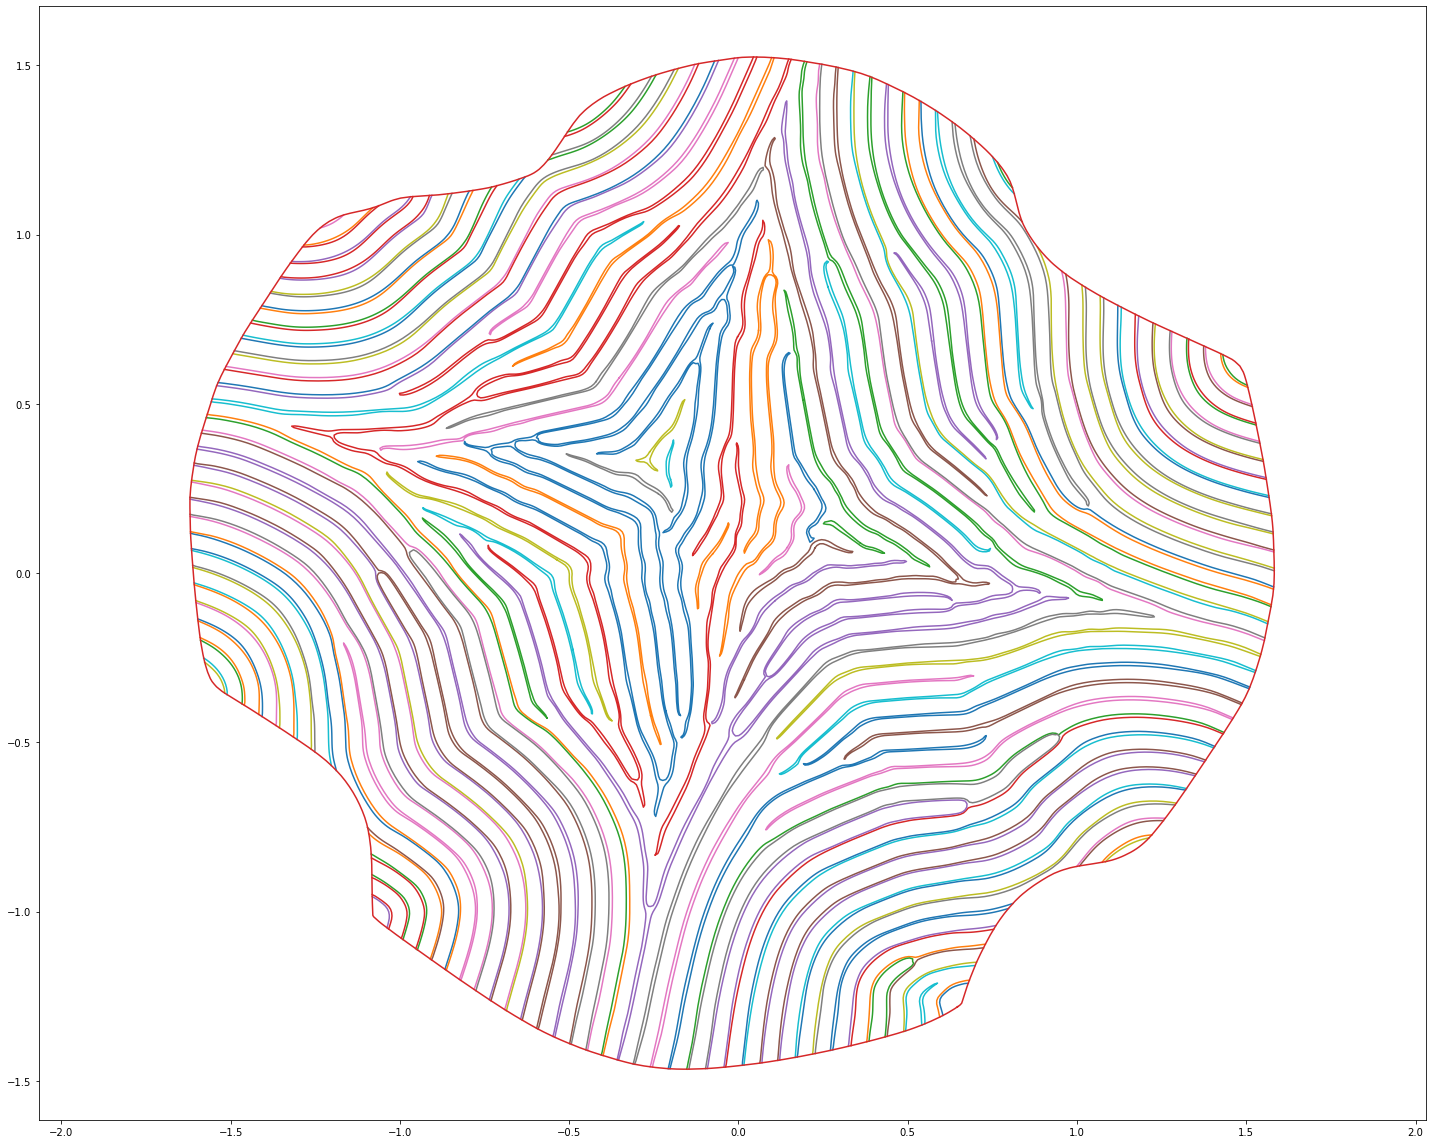

In [98]:
visualization.plot_line_segments(pts, edges, width=20, height=16)

In [123]:
import write_line_mesh
write_line_mesh.write_line_mesh('lilium_bend_reg_walls.obj', pts, edges)

## Meshing and inflation simulation

In [1]:
import parametrization, sparse_matrices, mesh, numpy as np, importlib, pickle, wall_generation
from tri_mesh_viewer import TriMeshViewer
import vis, matplotlib
from py_newton_optimizer import NewtonOptimizerOptions
from numpy.linalg import norm
from io_redirection import suppress_stdout
import visualization, wall_width_formulas as wwf

In [2]:
lilium = mesh.Mesh("../examples/lilium.msh")
lilium = lilium.subdivide_loop(1)

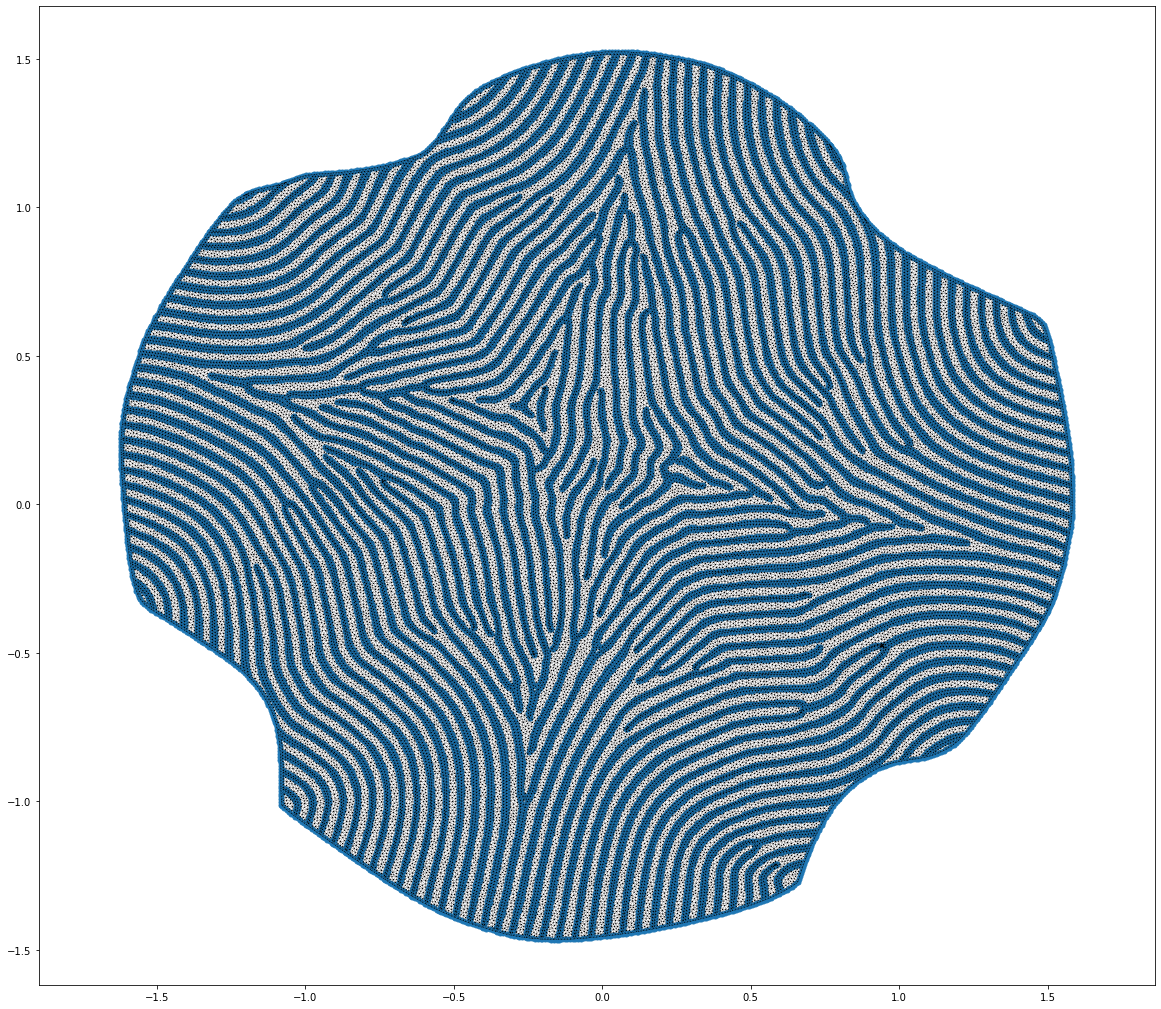

In [3]:
# m, fuseMarkers = wall_generation.triangulate_channel_walls(pts[:,0:2], edges, 0.00008)
# m.save('results/lilium_subdiv/top_sheet_5_f125.msh')
# np.savetxt('results/lilium_subdiv/fuse_markers_5_f125.txt', fuseMarkers)
m = mesh.Mesh('results/lilium_subdiv/top_sheet_5_f125.msh')
fuseMarkers = np.loadtxt('results/lilium_subdiv/fuse_markers_5_f125.txt')
visualization.plot_2d_mesh(m, pointList=np.where(np.array(fuseMarkers) == 1)[0], width=20, height=18)

In [4]:
import inflation
isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)
bv = isheet.mesh().boundaryVertices()
bdryVars = [isheet.varIdx(0, i, c) for i in bv for c in range(3)]

uv = np.loadtxt('results/lilium_subdiv/param_5.txt')
paramSampler = mesh.SurfaceSampler(np.pad(uv, [(0, 0), (0, 1)], 'constant'), lilium.triangles())
liftedSheetPositions = paramSampler.sample(m.vertices(), lilium.vertices())

In [9]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose())

In [12]:
import tri_mesh_viewer
importlib.reload(tri_mesh_viewer)
viewer = tri_mesh_viewer.TriMeshViewer(isheet.visualizationMesh(), width=1024, height=640)
#viewer.showWireframe()
viewer.setCameraParams(((2.855530256940937, 1.002991214638454, -1.1322350499425347),
 (-0.3303947111142514, -0.32128434449313503, -0.8874771573687668),
 (0.04746981475129009, 0.1255260177204086, 0.23082442618238475)))
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.6, children=(DirectionalLight(color='white', intensity=0.6, positio…

In [39]:
isheet.visualizationMesh().numTris()

274096

In [37]:
viewer.showWireframe(True)

In [25]:
import py_newton_optimizer
niter = 2000
iterations_per_output = 10
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-6
opts.niter = iterations_per_output

In [36]:
viewer.update(True, lilium)

In [38]:
viewer.update(True, isheet.visualizationMesh())

In [14]:
isheet.setUseTensionFieldEnergy(True)
isheet.setUseHessianProjectedEnergy(False)

In [15]:
targetAttractedSheet = inflation.TargetAttractedInflation(isheet, lilium)

In [31]:
targetAttractedSheet.energy(targetAttractedSheet.EnergyType.Fitting)

0.00111480397672175

In [16]:
isheet.setUninflatedDeformation(liftedSheetPositions.transpose(), prepareRigidMotionPinConstraints=False)

In [29]:
targetAttractedSheet.fittingWeight = 10

In [30]:
import time
inflation.benchmark_reset()
isheet.setUseTensionFieldEnergy(True)
isheet.setUseHessianProjectedEnergy(False)
niter = 5000
iterations_per_output = 20
opts.niter = iterations_per_output
isheet.pressure = 30
for step in range(int(niter / iterations_per_output)):
    cr = inflation.inflation_newton(targetAttractedSheet, [], opts)
    # cr = inflation.inflation_newton(isheet, isheet.rigidMotionPinVars, opts)
    viewer.update(False, isheet.visualizationMesh())
    time.sleep(0.01) # Allow some mesh synchronization time for pythreejs
    if cr.numIters() < iterations_per_output: break
inflation.benchmark_report()

Newton iterations	90.8963	3
    Newton iterate	90.7208	52
        Backtracking	3.95536	51
        Compute descent direction	82.4673	51
            newton_step	82.4381	51
                Newton solve	64.9577	51
                    CHOLMOD Numeric Factorize	60.4139	51
                    Solve	4.04068	51
                        CHOLMOD Backsub	4.01294	51
                hessEval	17.3003	51
CHOLMOD Symbolic Factorize	5.05302	3
Full time	98.7986


In [16]:
import fd_validation
fd_validation.validateGrad(isheet, fd_eps=1e-6)

(-1.993782916542841e-05, 1.5219155804113884e-06)

In [33]:
fd_validation.validateGrad(targetAttractedSheet, fd_eps=1e-7, etype=targetAttractedSheet.EnergyType.Full)

(3.8125058665627876e-06, 3.188512729683276e-06)

In [22]:
fd_validation.validateGrad(targetAttractedSheet, fd_eps=1e-7)

(-0.0001581090813829178, -0.0001579986751354369)

In [26]:
fd_validation.validateHessian(targetAttractedSheet, fd_eps=1e-8, etype=targetAttractedSheet.EnergyType.Full)

(0.00099982046354869,
 array([  0.22245774,   2.99238558,   2.47556343, ..., -17.52425522,
          3.99220029,   2.88551016]),
 array([  0.22245774,   2.99238558,   2.47556343, ..., -17.52425522,
          3.9922003 ,   2.88551016]))

In [34]:
H = targetAttractedSheet.hessian()

In [40]:
d = H.solve(-targetAttractedSheet.gradient())

In [41]:
np.dot(d, targetAttractedSheet.gradient())

-6.386540205872552e-10

In [13]:
xorig = targetAttractedSheet.getVars()

In [14]:
d = -targetAttractedSheet.gradient()

In [15]:
def energyAt(x):
    targetAttractedSheet.setVars(x)
    e, esim, efit = targetAttractedSheet.energy(), targetAttractedSheet.energy(targetAttractedSheet.EnergyType.Simulation), targetAttractedSheet.energy(targetAttractedSheet.EnergyType.Fitting)
    return (e, esim, efit)
stepLengths = np.linspace(0, 0.1, 200)
energies = [energyAt(xorig + sl * d) for sl in stepLengths]
targetAttractedSheet.setVars(xorig)

In [49]:
gfit = targetAttractedSheet.gradient(targetAttractedSheet.EnergyType.Fitting)
gsim = targetAttractedSheet.gradient(targetAttractedSheet.EnergyType.Simulation)
g    = targetAttractedSheet.gradient()

In [51]:
targetAttractedSheet.gradient(targetAttractedSheet.EnergyType.Simulation)

array([-6.26434337e-10,  1.52724090e-09, -1.55207640e-08, ...,
        3.70747270e-14,  2.32109254e-14, -7.99072180e-14])

In [55]:
np.argmax(np.abs(targetAttractedSheet.gradient()))

479

In [17]:
energiesSteepestDescent = np.array(energies)

In [105]:
energiesNewtonStep = np.array(energies)

In [43]:
norm(d)

0.0020695722531233578

In [46]:
norm(d) / norm(targetAttractedSheet.gradient())

70.22627214551973

In [50]:
targetAttractedSheet.energy()

-2.3595415276098777

In [51]:
targetAttractedSheet.setVars(xorig - 0.05 * g)

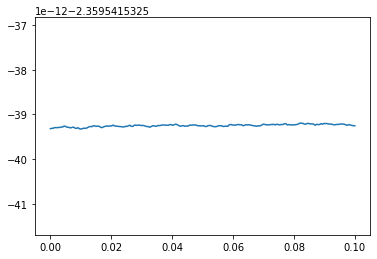

In [18]:
import matplotlib
from matplotlib import pyplot as plt
# plt.plot(stepLengths, energies[:, 0], stepLengths, energies[:, 1], stepLengths, energies[:, 2])
# plt.plot(stepLengths, energiesNewtonStep[:, 0], stepLengths, energiesSteepestDescent[:, 0])
plt.plot(stepLengths, energiesSteepestDescent[:, 0])
plt.show()

In [108]:
energiesSteepestDescent[-1, 0]

-2.3595415062275014

In [109]:
energiesSteepestDescent[0, 0]

-2.359541505747613

In [47]:
isheet.setUseTensionFieldEnergy(True)

In [49]:
fd_validation.validateHessian(isheet, fd_eps=1e-8, etype=isheet.EnergyType.Elastic)

(0.0007852253727547266,
 array([-1.6365945 ,  0.14772278, -0.07659388, ..., 13.54460695,
        11.80295171, -2.81433978]),
 array([-1.63659448,  0.14772281, -0.07659391, ..., 13.54460694,
        11.80295174, -2.81433977]))

In [49]:
isheet.tensionStateHistogram()

[8046, 39645, 112027]